# Laboratorio 4 - Tarea de agrupación: **VuelaAlpes**

**Grupo:** 33 <br>
**Integrantes:** Carolina Chinchilla & William Pollock

---

## Estructura del cuaderno

1. Configuración e importación
2. **Exploración de los datos y propuesta de limpieza/preparación**
3. **Modelamiento - tres algoritmos con pipelines reproducibles** 
   - 3.1 K-Means
   - 3.2 Clustering Jerárquico (Ward)
   - 3.3 DBSCAN


---

## 1. Configuración e importación de librerías

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Exploración de los datos y propuesta de limpieza

Cargamos el dataset y revisamos su estructura, tipos, valores faltantes, duplicados, estadísticas descriptivas, distribuciones y correlaciones, para identificar problemas de calidad antes de modelar.

In [2]:
df = pd.read_csv('Datos_VuelaAlpes.csv')
print('Forma del dataset:', df.shape)
df.head()

Forma del dataset: (10000, 23)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0


In [4]:
dicc = pd.read_excel('Diccionario VuelaAlpes.xlsx')
dicc

,Variable,Tipo,Descripción
0,id,Entero,Identificador único del pasajero
1,Gender,Texto,Género del pasajero (Male / Female)
2,Customer Type,Texto,Tipo de cliente (Loyal Customer / disloyal Cus...
3,Age,Entero,Edad del pasajero
4,Type of Travel,Texto,Tipo de viaje (Business / Personal)
5,Class,Texto,"Clase del vuelo (Eco, Eco Plus, Business)"
6,Flight Distance,Entero,Distancia del vuelo
7,Inflight wifi service,Entero,Calificación del wifi (0–5)
8,Departure/Arrival time convenient,Entero,Conveniencia del horario (0–5)
9,Ease of Online booking,Entero,Facilidad de reserva online (0–5)


### 2.1 Tipos y resumen general

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  str    
 2   Customer Type                      10000 non-null  str    
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  str    
 5   Class                              10000 non-null  str    
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int64  
 12  On

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.0,NaN,NaN,NaN,64983.0585,37610.205164,1.0,32452.0,64815.5,97470.0,129879.0
Gender,10000,2,Female,5140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,10000,2,Loyal Customer,8155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,39.4043,15.072364,7.0,27.0,40.0,51.0,80.0
Type of Travel,10000,2,Business travel,6934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,10000,3,Business,4856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,10000.0,NaN,NaN,NaN,1196.0448,1000.590808,31.0,416.0,846.0,1744.0,4963.0
Inflight wifi service,10000.0,NaN,NaN,NaN,2.7347,1.328718,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,10000.0,NaN,NaN,NaN,3.074,1.520511,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,10000.0,NaN,NaN,NaN,2.7626,1.394287,0.0,2.0,3.0,4.0,5.0


### 2.2 Calidad de datos: completitud, unicidad, validez

In [7]:
na = df.isnull().sum()
na = na[na > 0].sort_values(ascending=False)
print('Variables con valores faltantes:')
print(na if len(na) > 0 else 'Ninguna')
print(f'\nTotal de filas con al menos un NA: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).mean()*100:.2f}%)')

Variables con valores faltantes:
Arrival Delay in Minutes    25
dtype: int64

Total de filas con al menos un NA: 25 (0.25%)


In [8]:
print(f'Filas duplicadas (todas las columnas): {df.duplicated().sum()}')
print(f'IDs duplicados: {df["id"].duplicated().sum()}')

Filas duplicadas (todas las columnas): 0
IDs duplicados: 0


In [9]:
rating_cols = [
    'Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking',
    'Gate location','Food and drink','Online boarding','Seat comfort','Inflight entertainment',
    'On-board service','Leg room service','Baggage handling','Checkin service',
    'Inflight service','Cleanliness'
]
ceros = pd.DataFrame({
    'n_ceros': [(df[c]==0).sum() for c in rating_cols],
    'pct_ceros': [(df[c]==0).mean()*100 for c in rating_cols]
}, index=rating_cols).sort_values('pct_ceros', ascending=False)
ceros

,n_ceros,pct_ceros
Departure/Arrival time convenient,529,5.29
Ease of Online booking,446,4.46
Inflight wifi service,310,3.10
Online boarding,251,2.51
Leg room service,40,0.40
Food and drink,4,0.04
Gate location,0,0.00
Seat comfort,0,0.00
Inflight entertainment,0,0.00
On-board service,0,0.00


**Observación importante:** las calificaciones están documentadas en el diccionario como '0-5'. En la mayoría de datasets de satisfacción aerolínea como éste, el valor '0' se usa para indicar **"no aplica" o "sin respuesta"** (por ejemplo, no se puede calificar wifi si el pasajero no lo usó). Sin embargo, no tenemos confirmación explícita en el diccionario, así que decidimos **mantener los ceros como una categoría válida de la escala**. Esto nos servirá luego para identificar segmentos que "no utilizan" ciertos servicios.

### 2.3 Distribuciones de variables numéricas

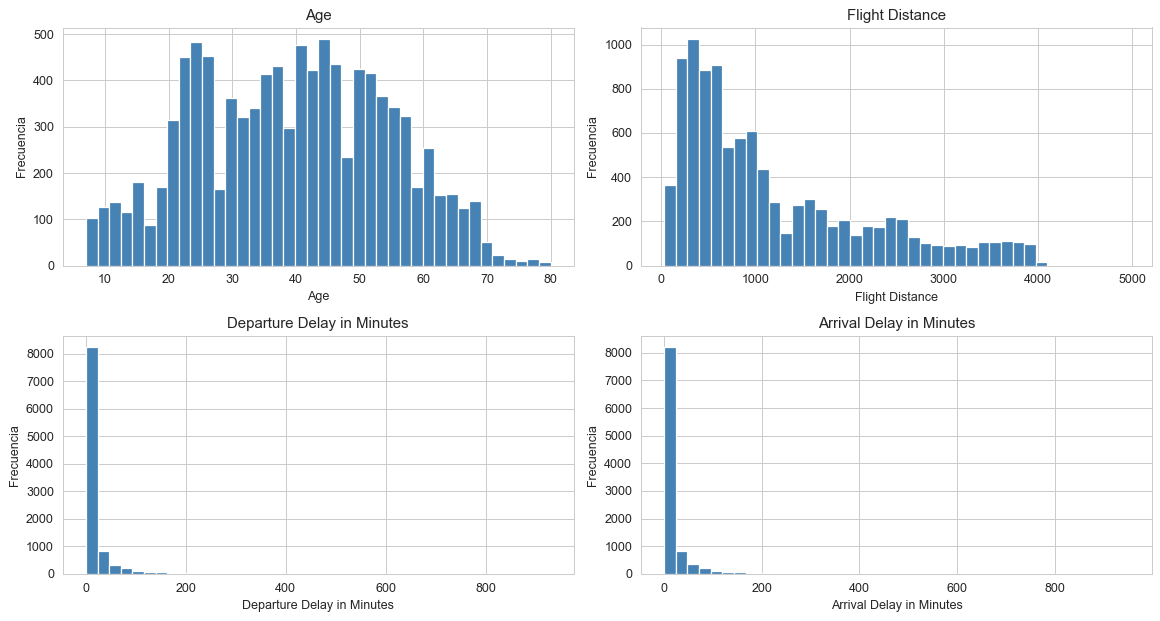

In [10]:
num_cols_base = ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num_cols_base):
    df[c].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(c)
    ax.set_xlabel(c); ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

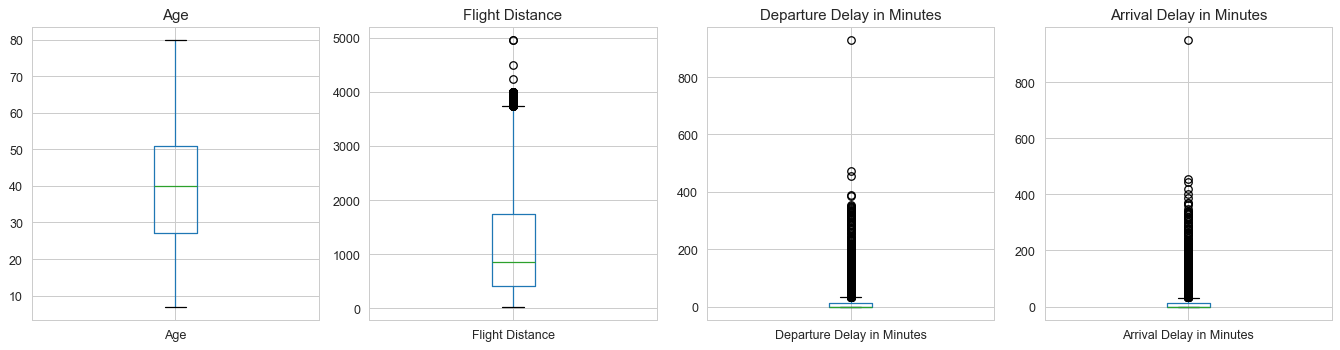

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, c in zip(axes, num_cols_base):
    df.boxplot(column=c, ax=ax)
    ax.set_title(c)
plt.tight_layout(); plt.show()

**Hallazgos clave:**

- 'Age' es aproximadamente simétrica entre 7 y 85 años (sin outliers extremos).
- 'Flight Distance' tiene cola derecha - la mayoría son vuelos cortos/medios.
- 'Departure Delay' y 'Arrival Delay' están **fuertemente sesgados a la derecha** y contienen outliers muy extremos (retrasos de hasta ~16 horas). Esto es realista en aerolíneas, pero exigirá tratamiento (transformación logarítmica) porque los algoritmos basados en distancia, como K-Means, son muy sensibles a outliers.

### 2.4 Distribuciones de variables categóricas

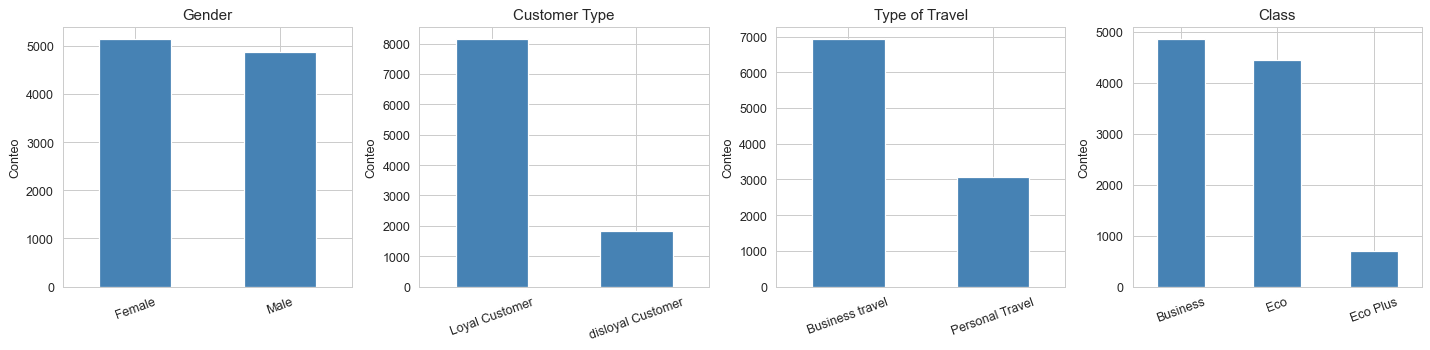

In [12]:
cat_cols = ['Gender','Customer Type','Type of Travel','Class']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, cat_cols):
    df[c].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(c); ax.set_xlabel(''); ax.set_ylabel('Conteo')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Observaciones:**

- 'Gender': dataset balanceado (≈51% Female, ≈49% Male).
- 'Customer Type': predominio de clientes leales (~82%) vs. desleales (~18%).
- 'Type of Travel': predominio Business travel (~69%).
- 'Class': Business y Eco están equilibradas, Eco Plus es minoría (~7%).

### 2.5 Distribuciones de las calificaciones del servicio

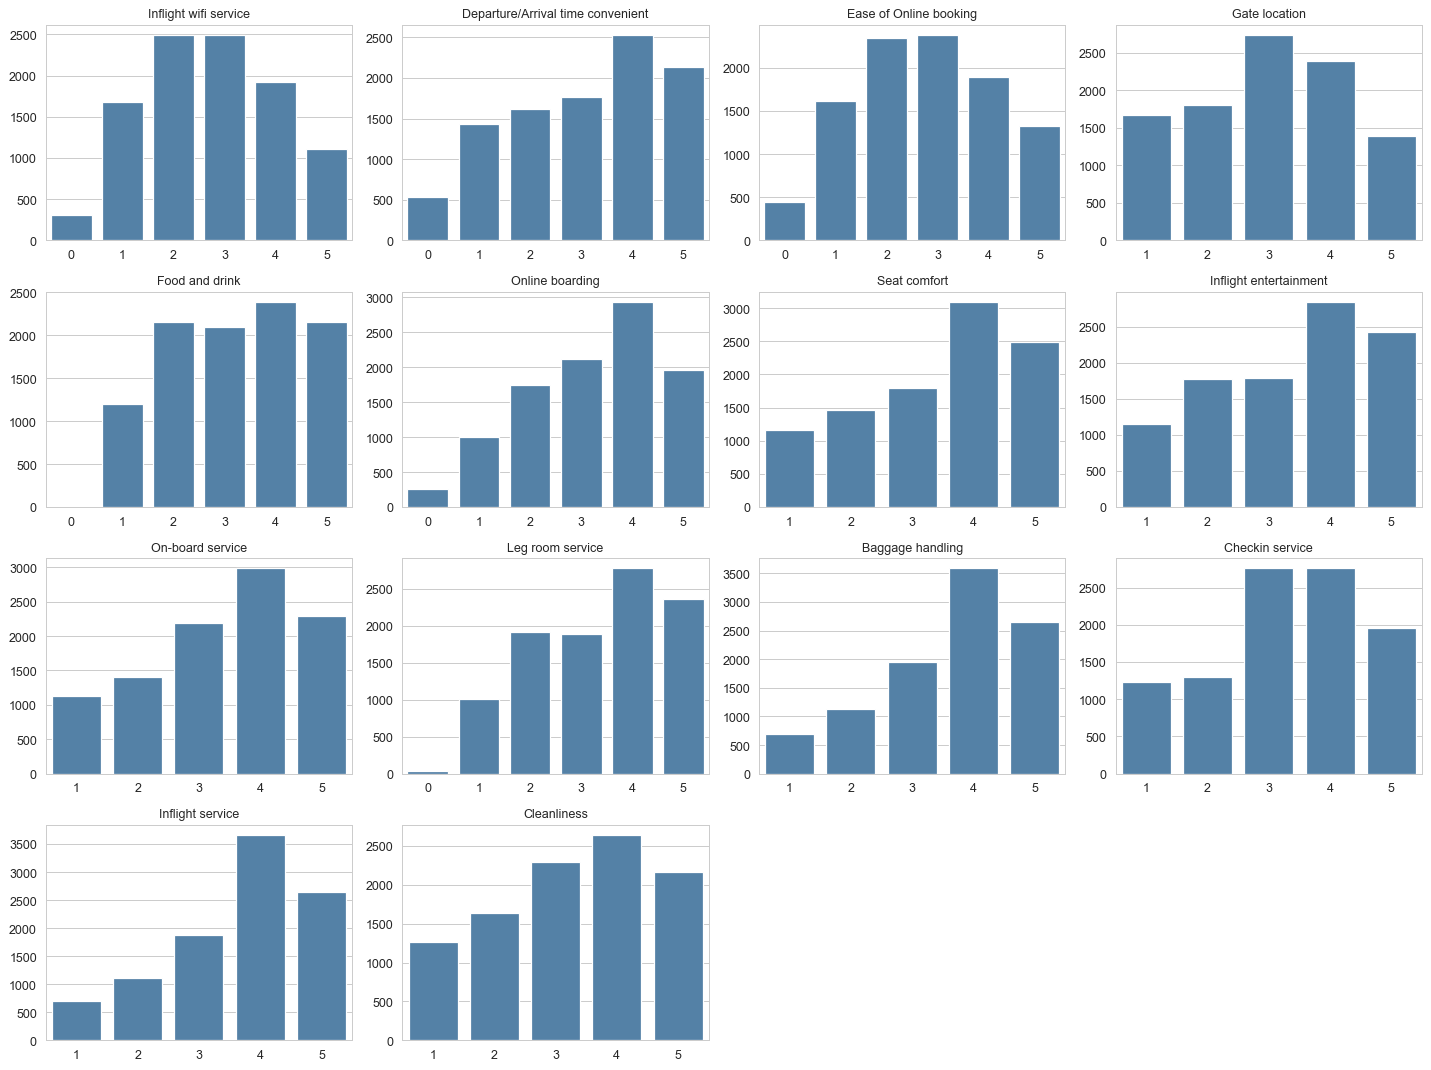

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for i, c in enumerate(rating_cols):
    sns.countplot(x=df[c], ax=axes[i], color='steelblue')
    axes[i].set_title(c, fontsize=10)
    axes[i].set_xlabel(''); axes[i].set_ylabel('')
for j in range(len(rating_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

La mayoría de calificaciones se distribuyen entre 3 y 5, con presencia de 0 (no aplica/no respuesta) en varias variables, y de 1-2 que representan insatisfacción. **No hay una calificación dominante uniforme**; esto es buena señal para clustering porque sugiere que existen perfiles diferentes en cómo evalúan los pasajeros.

### 2.6 Correlaciones entre variables numéricas y de calificación

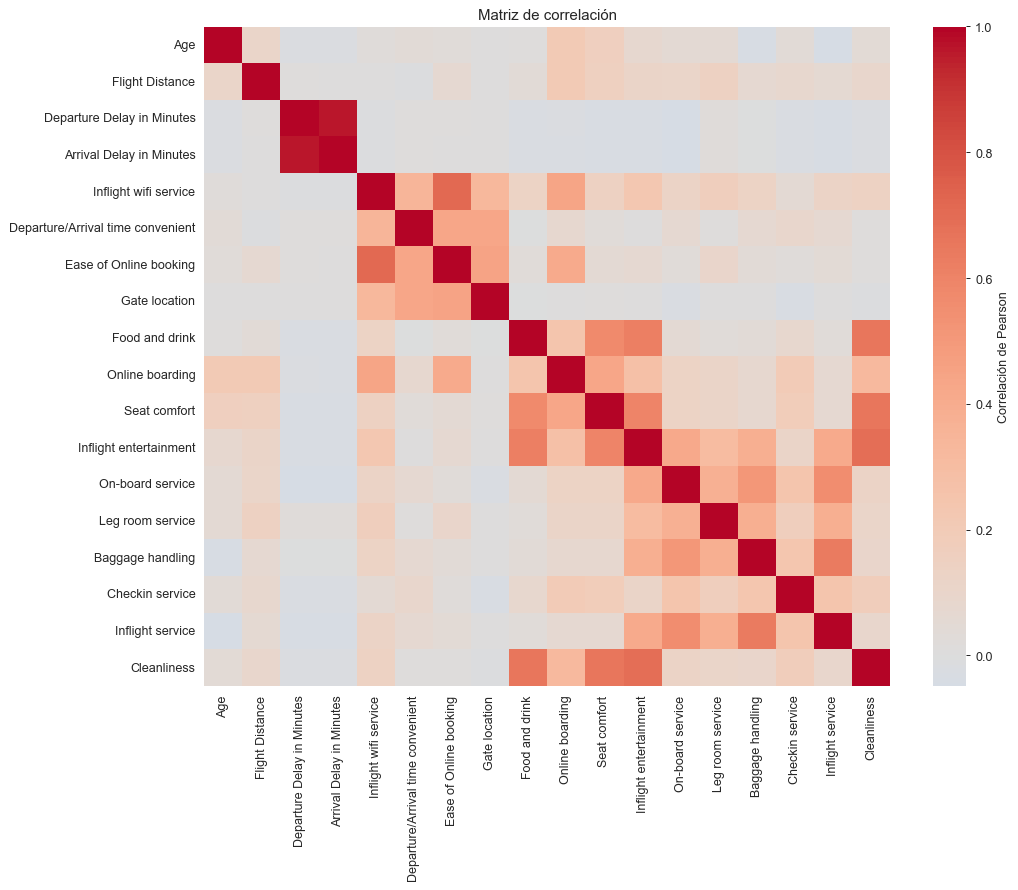

In [14]:
corr_cols = num_cols_base + rating_cols
plt.figure(figsize=(12, 10))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', center=0, annot=False,
            cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación')
plt.tight_layout(); plt.show()

In [15]:
corr = df[corr_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pares = upper.unstack().dropna().sort_values(ascending=False).head(10)
print('Pares con mayor correlación absoluta:')
print(pares.to_string())

Pares con mayor correlación absoluta:
Arrival Delay in Minutes  Departure Delay in Minutes    0.962373
Ease of Online booking    Inflight wifi service         0.713721
Cleanliness               Inflight entertainment        0.688566
                          Food and drink                0.662889
                          Seat comfort                  0.661516
Inflight service          Baggage handling              0.632737
Inflight entertainment    Food and drink                0.619714
                          Seat comfort                  0.602581
Seat comfort              Food and drink                0.570611
Inflight service          On-board service              0.559110


**Hallazgos:**

- 'Departure Delay' y 'Arrival Delay' están casi perfectamente correlacionadas (≈0.97). Conservamos ambas pero es redundancia que conviene tener en mente.
- 'Ease of Online booking' <-> 'Inflight wifi service' y otros pares de calificaciones digitales muestran correlaciones altas, lo cual sugiere un eje latente de "satisfacción con servicios digitales".
- 'Cleanliness' correlaciona con 'Inflight entertainment', 'Food and drink' y 'Seat comfor' - eje latente de "calidad a bordo".

### 2.7 Propuesta de limpieza y preparación

Las decisiones tomadas y sus justificaciones:

| Decisión | Justificación |
|---|---|
| **Eliminar 'id'** | Es un identificador único sin información para clustering. |
| **Imputar 25 NA de 'Arrival Delay' con la mediana** | Son apenas 0.25% del dataset y la variable tiene distribución muy sesgada, por lo que la mediana es más robusta que la media. |
| **Mantener '0' en calificaciones como categoría válida** | El diccionario documenta la escala como 0-5; no podemos confirmar que sea "no aplica". Si fuera relevante, lo descubrimos en la interpretación. |
| **Transformación 'log1p' a delays** | Reduce el efecto de outliers extremos sin eliminarlos (preservamos información), mejor para algoritmos basados en distancia. |
| **'StandardScaler' a numéricas** | K-Means y métricas Euclidianas requieren escalas comparables. |
| **'OneHotEncoder' a categóricas** | Variables nominales sin orden natural; usamos drop='if_binary' para evitar redundancia en variables binarias. |
| **No eliminar duplicados** | No existen filas duplicadas. |
| **No eliminar outliers extremos en delay** | Tras 'log1p' ya están comprimidos; eliminarlos descartaría información válida (vuelos muy retrasados existen y son segmento de negocio relevante). |
| **No usar PCA en el pipeline de modelamiento** | Si lo incluyéramos, perderíamos interpretabilidad de los segmentos en términos de las variables originales. |

In [16]:
# aplicar la limpieza
df_clean = df.copy()
df_clean = df_clean.drop(columns=['id'])


mediana_arr = df_clean['Arrival Delay in Minutes'].median()
n_imp = df_clean['Arrival Delay in Minutes'].isnull().sum()
df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(mediana_arr)
print(f'Imputados {n_imp} NA en Arrival Delay con la mediana = {mediana_arr}')


df_clean['Departure Delay in Minutes'] = np.log1p(df_clean['Departure Delay in Minutes'])
df_clean['Arrival Delay in Minutes']   = np.log1p(df_clean['Arrival Delay in Minutes'])
print('Aplicado log1p a Departure Delay y Arrival Delay')

print('\nDataset final tras limpieza:')
print(df_clean.shape)
df_clean.head()

Imputados 25 NA en Arrival Delay con la mediana = 0.0
Aplicado log1p a Departure Delay y Arrival Delay

Dataset final tras limpieza:
(10000, 22)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,...,4,4,4,2,5,4,4,4,2.302585,1.945910
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,...,4,4,4,4,4,4,4,4,3.295837,2.302585
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,...,4,4,4,4,4,3,4,4,4.234107,3.761200
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,...,1,4,4,2,5,4,5,4,2.079442,3.688879
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,...,3,3,5,5,4,5,4,3,0.000000,0.000000


In [17]:
num_cols = ['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes'] + rating_cols
cat_cols = ['Gender','Customer Type','Type of Travel','Class']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)


X_proc = preprocessor.fit_transform(df_clean)
print('Forma del dataset preprocesado:', X_proc.shape)


feat_names = list(num_cols) + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
print(f'Total de features tras one-hot: {len(feat_names)}')

Forma del dataset preprocesado: (10000, 24)
Total de features tras one-hot: 24


In [18]:
# sub-muestra para algoritmos que sean muy costosos/demorados
SAMPLE_SIZE = 3000
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_proc.shape[0], size=SAMPLE_SIZE, replace=False
)
X_sample = X_proc[sample_idx]
df_sample = df_clean.iloc[sample_idx].reset_index(drop=True)
print(f'Sub-muestra para Jerárquico/DBSCAN: {X_sample.shape}')

Sub-muestra para Jerárquico/DBSCAN: (3000, 24)


## 3. Modelamiento - Tres algoritmos de agrupación

Aplicaremos tres algoritmos con paradigmas distintos para comparar:

| Algoritmo | Tipo | Supuestos / restricciones |
|---|---|---|
| **K-Means** | Particional, basado en centroides | Asume clusters esféricos de tamaño similar; requiere fijar 'k'; sensible a outliers y a escalamiento. |
| **Clustering jerárquico** | Aglomerativo, basado en distancia | No requiere fijar 'k' de antemano (se elige a partir del dendrograma); favorece clusters compactos y tiene costo O(n^2) en memoria. |
| **DBSCAN** | Basado en densidad | Detecta clusters de forma arbitraria y outliers (ruido); requiere 'eps' y 'min_samples'; sufre con dimensionalidad alta. |

Cada modelo se construye con un **pipeline reproducible** que integra preprocesamiento + clustering, y todos los hiperparámetros se buscan de manera ordenada y justificada.

### 3.1 K-Means

**Lógica del algoritmo:** divide los datos en 'k' grupos minimizando la **suma de distancias cuadradas** de cada punto a su centroide. Es un algoritmo iterativo (asignación -> re-cálculo de centroides -> repetir hasta convergencia).

**Supuestos / restricciones:**
- Clusters convexos y de tamaño similar.
- Requiere fijar 'k' antes de entrenar.
- Sensible a la inicialización (mitigado con 'n_init=10').
- Sensible a outliers y a la escala de las variables (por eso aplicamos 'StandardScaler').

**Pertinencia para VuelaAlpes:** es el algoritmo más estándar para segmentación de clientes; escala bien a los 10000 pasajeros y permite **asignar fácilmente nuevos pasajeros futuros** al cluster correspondiente sin reentrenar.

**Búsqueda de hiperparámetro 'k'** mediante método del codo/inercia y silueta.

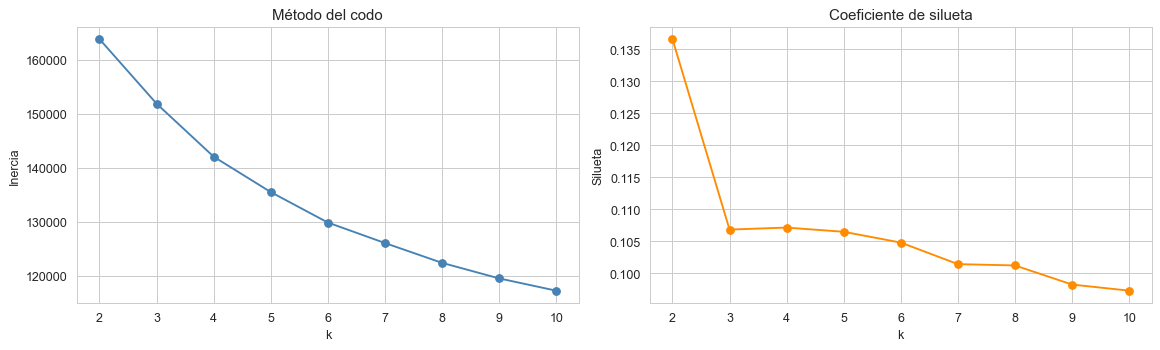


Resultados por k:
  k=2: inercia=163856.41, silueta=0.1366
  k=3: inercia=151901.04, silueta=0.1068
  k=4: inercia=142080.00, silueta=0.1071
  k=5: inercia=135524.32, silueta=0.1065
  k=6: inercia=129883.71, silueta=0.1048
  k=7: inercia=126087.86, silueta=0.1014
  k=8: inercia=122418.27, silueta=0.1012
  k=9: inercia=119535.78, silueta=0.0982
  k=10: inercia=117262.13, silueta=0.0973


In [19]:
ks = list(range(2, 11))
inertia, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_proc)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_proc, labels, sample_size=3000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inertia, 'o-', color='steelblue'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo'); axes[0].grid(True)
axes[1].plot(ks, silhouettes, 'o-', color='darkorange'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silueta')
axes[1].set_title('Coeficiente de silueta'); axes[1].grid(True)
plt.tight_layout(); plt.show()

print('\nResultados por k:')
for k, i, s in zip(ks, inertia, silhouettes):
    print(f'  k={k}: inercia={i:.2f}, silueta={s:.4f}')

**Lectura:**

- La inercia disminuye monótonamente, con un codo modesto entre k=3 y k=5.
- La silueta es máxima en k=2 y decae luego - esto es común cuando hay un eje principal de variación dominante.
- **Decisión:** entrenamos el pipeline final con k=4 porque, aunque k=2 tiene silueta marginalmente superior, dos grupos son demasiado gruesos para acciones de negocio diferenciadas. k=4 ofrece mayor riqueza de segmentación con muy poca pérdida de cohesión. También reportamos k=2 para comparabilidad.

In [21]:
BEST_K_KM = 4

pipe_kmeans = Pipeline([
    ('prep', preprocessor),
    ('cluster', KMeans(n_clusters=BEST_K_KM, random_state=RANDOM_STATE, n_init=10))
])
labels_kmeans = pipe_kmeans.fit_predict(df_clean)

sil_km = silhouette_score(X_proc, labels_kmeans, sample_size=3000, random_state=RANDOM_STATE)
db_km  = davies_bouldin_score(X_proc, labels_kmeans)
ch_km  = calinski_harabasz_score(X_proc, labels_kmeans)

print(f'K-Means con k={BEST_K_KM}')
print(f'  Silueta:           {sil_km:.4f}')
print(f'  Davies-Bouldin:    {db_km:.4f}')
print(f'  Calinski-Harabasz: {ch_km:.2f}')
print(f'  Tamaños de grupos: {pd.Series(labels_kmeans).value_counts().sort_index().to_dict()}')

K-Means con k=4
  Silueta:           0.1071
  Davies-Bouldin:    2.3956
  Calinski-Harabasz: 1164.80
  Tamaños de grupos: {0: 2410, 1: 2398, 2: 2735, 3: 2457}


In [22]:
pipe_kmeans2 = Pipeline([
    ('prep', preprocessor),
    ('cluster', KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10))
])
labels_kmeans2 = pipe_kmeans2.fit_predict(df_clean)

sil_km2 = silhouette_score(X_proc, labels_kmeans2, sample_size=3000, random_state=RANDOM_STATE)
db_km2  = davies_bouldin_score(X_proc, labels_kmeans2)
ch_km2  = calinski_harabasz_score(X_proc, labels_kmeans2)

print(f'K-Means con k=2 (alternativo)')
print(f'  Silueta:           {sil_km2:.4f}')
print(f'  Davies-Bouldin:    {db_km2:.4f}')
print(f'  Calinski-Harabasz: {ch_km2:.2f}')
print(f'  Tamaños:           {pd.Series(labels_kmeans2).value_counts().sort_index().to_dict()}')

K-Means con k=2 (alternativo)
  Silueta:           0.1366
  Davies-Bouldin:    2.3770
  Calinski-Harabasz: 1701.86
  Tamaños:           {0: 5442, 1: 4558}


### 3.2 Clustering jerárquico

**Lógica del algoritmo:** parte con cada punto como su propio cluster y los va fusionando iterativamente. En cada paso fusiona los dos clusters más cercanos según un criterio de enlace (linkage). Usamos **Ward**, que minimiza el incremento de varianza intra-cluster al fusionar.

**Supuestos / restricciones:**
- Complejidad **O(n^2)** en memoria y **O(n^3)** en tiempo - inviable sobre 10000 filas, obligando a sub-muestra de 3000.
- Cada fusión es irreversible - un mal split temprano no se corrige.
- El número de clusters se elige post-hoc a partir del dendrograma.
- Ward favorece clusters compactos y de tamaños similares.

**Pertinencia para VuelaAlpes:** sirve como **validación cruzada** de los hallazgos de K-Means. Si dos algoritmos distintos llegan a estructuras similares, ganamos confianza en que los grupos reflejan patrones reales y no artefactos de un único algoritmo.

Visualizamos el **dendrograma** sobre la sub-muestra para escoger el número de clusters por inspección visual y por silueta.

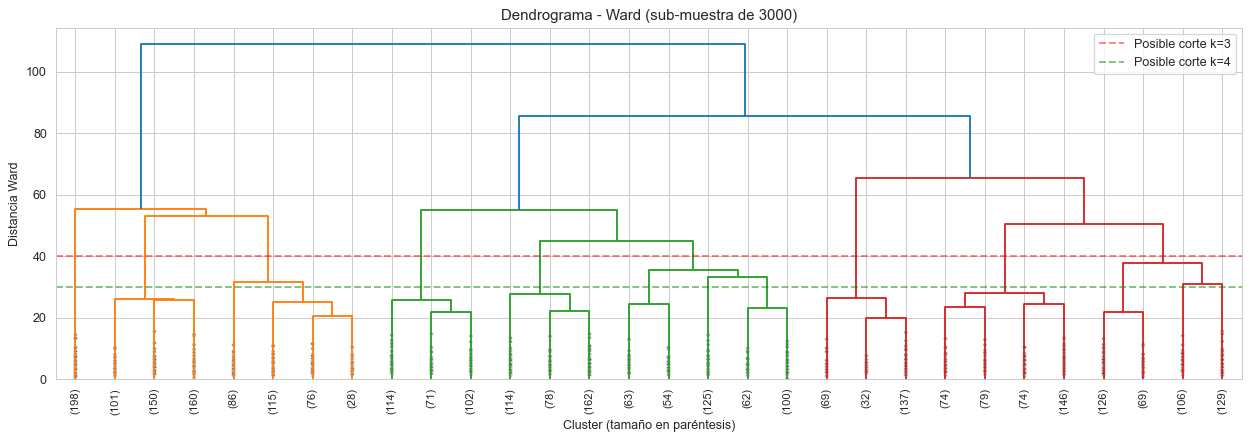

In [24]:
plt.figure(figsize=(14, 5))
Z = linkage(X_sample, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.title('Dendrograma - Ward (sub-muestra de 3000)')
plt.xlabel('Cluster (tamaño en paréntesis)')
plt.ylabel('Distancia Ward')
plt.axhline(y=40, color='red', linestyle='--', alpha=0.5, label='Posible corte k=3')
plt.axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Posible corte k=4')
plt.legend()
plt.tight_layout(); plt.show()

 k  silueta     DB       CH
 2   0.0921 2.5697 345.4269
 3   0.0858 2.9048 300.5166
 4   0.0805 2.6585 256.3249
 5   0.0569 2.4889 224.6845
 6   0.0546 2.5317 207.2941
 7   0.0480 2.4442 195.5223


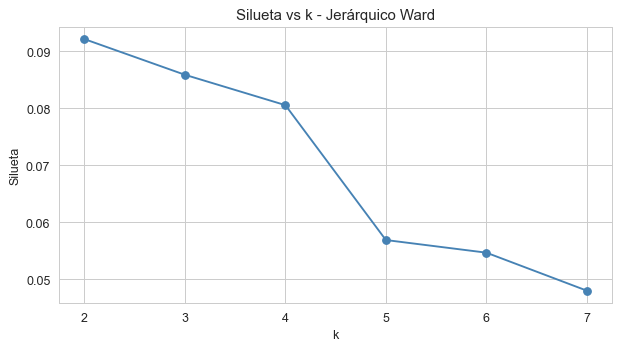

In [26]:
sils_h, dbs_h, chs_h = [], [], []
ks_h = list(range(2, 8))
for k in ks_h:
    h = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = h.fit_predict(X_sample)
    sils_h.append(silhouette_score(X_sample, labels))
    dbs_h.append(davies_bouldin_score(X_sample, labels))
    chs_h.append(calinski_harabasz_score(X_sample, labels))

resh = pd.DataFrame({'k': ks_h, 'silueta': sils_h, 'DB': dbs_h, 'CH': chs_h}).round(4)
print(resh.to_string(index=False))

plt.figure(figsize=(7,4))
plt.plot(ks_h, sils_h, 'o-', color='steelblue')
plt.xlabel('k'); plt.ylabel('Silueta'); plt.title('Silueta vs k - Jerárquico Ward'); plt.grid(True)
plt.tight_layout(); plt.show()

In [27]:
BEST_K_H = ks_h[int(np.argmax(sils_h))]
print(f'Mejor k por silueta: {BEST_K_H}')

h_final = AgglomerativeClustering(n_clusters=BEST_K_H, linkage='ward')
labels_h = h_final.fit_predict(X_sample)

sil_h = silhouette_score(X_sample, labels_h)
db_h  = davies_bouldin_score(X_sample, labels_h)
ch_h  = calinski_harabasz_score(X_sample, labels_h)

print(f'\nJerárquico Ward (k={BEST_K_H})')
print(f'  Silueta:           {sil_h:.4f}')
print(f'  Davies-Bouldin:    {db_h:.4f}')
print(f'  Calinski-Harabasz: {ch_h:.2f}')
print(f'  Tamaños:           {pd.Series(labels_h).value_counts().sort_index().to_dict()}')

Mejor k por silueta: 2

Jerárquico Ward (k=2)
  Silueta:           0.0921
  Davies-Bouldin:    2.5697
  Calinski-Harabasz: 345.43
  Tamaños:           {0: 2086, 1: 914}


In [28]:
h_final4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_h4 = h_final4.fit_predict(X_sample)
sil_h4 = silhouette_score(X_sample, labels_h4)
db_h4  = davies_bouldin_score(X_sample, labels_h4)
ch_h4  = calinski_harabasz_score(X_sample, labels_h4)
print(f'Jerárquico Ward k=4 (comparativo): sil={sil_h4:.4f}, DB={db_h4:.4f}, CH={ch_h4:.2f}')
print(f'Tamaños: {pd.Series(labels_h4).value_counts().sort_index().to_dict()}')

Jerárquico Ward k=4 (comparativo): sil=0.0805, DB=2.6585, CH=256.32
Tamaños: {0: 914, 1: 803, 2: 1045, 3: 238}


### 3.3 DBSCAN

**Lógica del algoritmo:** identifica regiones densas de puntos y las agrupa. Un punto es **núcleo** si tiene al menos 'min_samples' vecinos dentro de un radio 'eps'. Los clusters se forman conectando puntos núcleo con sus vecinos; los puntos que no caen en ninguna región densa se etiquetan como **ruido (-1)**.

**Supuestos / restricciones:**
- Sufre la **maldición de la dimensionalidad:** en espacios con muchas features, las distancias entre puntos se vuelven más uniformes y se hace difícil distinguir regiones densas.
- Muy sensible a 'eps' y 'min_samples'.
- Asigna puntos como ruido, lo que es bueno para detectar outliers pero **limita la cobertura** para segmentación operativa.
- No requiere fijar k de antemano.

**Pertinencia para VuelaAlpes:** sirve para **detectar perfiles atípicos** (pasajeros muy diferentes a la mayoría) y para verificar si existen clusters de forma no convexa que K-Means no captura.

Para encontrar un buen 'eps' usamos el método del **gráfico de la k-ésima distancia más cercana** (k-distance graph). Regla de pulgar para 'min_samples': cercano a '2 x dimensionalidad'.

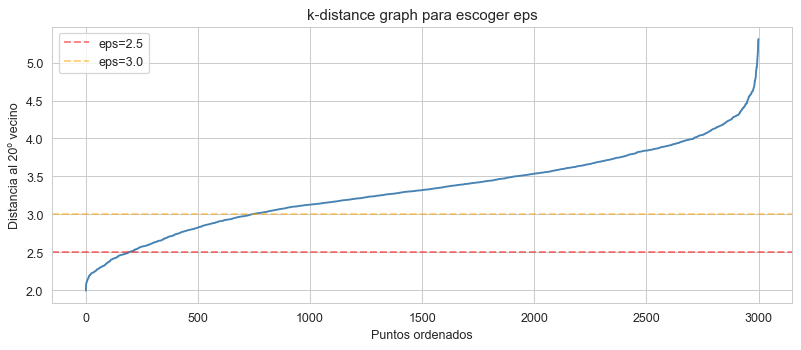

In [29]:
MIN_SAMPLES = 20

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
k_dist = np.sort(dist[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color='steelblue')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {MIN_SAMPLES}º vecino')
plt.title('k-distance graph para escoger eps')
plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='eps=2.5')
plt.axhline(y=3.0, color='orange', linestyle='--', alpha=0.5, label='eps=3.0')
plt.legend()
plt.grid(True); plt.tight_layout(); plt.show()

In [30]:
resultados_db = []
for eps in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_sample)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = n_noise / len(labels) * 100
    sil = None
    if n_clust > 1:
        mask = labels != -1
        if mask.sum() > 10:
            try:
                sil = silhouette_score(X_sample[mask], labels[mask])
            except Exception:
                sil = None
    resultados_db.append({'eps': eps, 'min_samples': MIN_SAMPLES,
                          'n_clusters': n_clust, 'pct_ruido': pct_noise,
                          'silueta_sin_ruido': sil})

res_db = pd.DataFrame(resultados_db)
print(res_db.to_string(index=False))

 eps  min_samples  n_clusters  pct_ruido  silueta_sin_ruido
 1.5           20           0 100.000000                NaN
 2.0           20           1  99.300000                NaN
 2.5           20           2  82.800000           0.057635
 3.0           20           1  41.433333                NaN
 3.5           20           1   5.400000                NaN
 4.0           20           1   0.366667                NaN


In [31]:
EPS_FINAL = 2.5
db_final = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES)
labels_db = db_final.fit_predict(X_sample)

n_clust_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
mask = labels_db != -1

sil_db = silhouette_score(X_sample[mask], labels_db[mask]) if (mask.sum() > 10 and n_clust_db > 1) else np.nan
db_dbsc = davies_bouldin_score(X_sample[mask], labels_db[mask]) if (mask.sum() > 10 and n_clust_db > 1) else np.nan
ch_dbsc = calinski_harabasz_score(X_sample[mask], labels_db[mask]) if (mask.sum() > 10 and n_clust_db > 1) else np.nan

print(f'DBSCAN (eps={EPS_FINAL}, min_samples={MIN_SAMPLES})')
print(f'  N° clusters:       {n_clust_db}')
print(f'  Puntos de ruido:   {n_noise_db} ({n_noise_db/len(labels_db)*100:.2f}%)')
print(f'  Silueta:           {sil_db:.4f}')
print(f'  Davies-Bouldin:    {db_dbsc:.4f}')
print(f'  Calinski-Harabasz: {ch_dbsc:.2f}')
print(f'  Tamaños:           {pd.Series(labels_db).value_counts().sort_index().to_dict()}')

DBSCAN (eps=2.5, min_samples=20)
  N° clusters:       2
  Puntos de ruido:   2484 (82.80%)
  Silueta:           0.0576
  Davies-Bouldin:    1.8284
  Calinski-Harabasz: 11.96
  Tamaños:           {-1: 2484, 0: 500, 1: 16}


**Nota sobre DBSCAN:** en datos de alta dimensionalidad como éstos (24 features tras one-hot), DBSCAN típicamente sufre la "maldición de la dimensionalidad" - las distancias entre puntos se vuelven más uniformes y se hace difícil encontrar regiones densas. El alto porcentaje de ruido observado es esperable y es una **restricción del algoritmo**, no un defecto de los datos.